In [2]:
import polars as pl
import json
import sys
import sklearn
from matplotlib import pyplot as plt
import os
import numpy as np
import random

In [3]:
PERCENTILES = (0.1, 1, 2.5, 5, 10, 25, 50, 75, 90, 95, 97.5, 99, 99.9)

COL_NAMES = [
    'fs'
]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import polars as pl
from collections import Counter


NUMERIC_DTYPES = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}


def plot_histograms_and_stats(
    dfs: list[pl.DataFrame],
    COL_NAMES,
    bins=50,
    percentiles=PERCENTILES,
    figsize_per_ax=(4, 3),
    top_k_categorical=20,       # limit categorical values for plotting
):
    num_dfs = len(dfs)
    stats_results = {}

    for col in COL_NAMES:
        print(f"\n==========={col}=========")
        # =====================================================
        # Global numeric range (for shared x-axis on numeric)
        # =====================================================
        global_x = []
        for df in dfs:
            if col in df.columns and df[col].dtype in NUMERIC_DTYPES:
                arr = df[col].drop_nulls().to_numpy()
                if arr.size > 0:
                    global_x.append(arr)

        if len(global_x) > 0:
            global_x = np.concatenate(global_x)
            global_min, global_max = global_x.min(), global_x.max()
        else:
            global_min = global_max = None

        # =====================================================
        # Global categorical categories (for shared x-axis)
        # =====================================================
        global_cat_counter = Counter()
        for df in dfs:
            if col in df.columns and df[col].dtype not in NUMERIC_DTYPES:
                vals = df[col].drop_nulls().to_list()
                if len(vals) > 0:
                    global_cat_counter.update(vals)

        if len(global_cat_counter) > 0:
            # Top-K most common categories, consistent order
            global_cats = [cat for cat, _ in global_cat_counter.most_common(top_k_categorical)]
        else:
            global_cats = []

        fig, axes = plt.subplots(
            1, num_dfs,
            figsize=(figsize_per_ax[0] * num_dfs, figsize_per_ax[1]),
            squeeze=False
        )
        axes = axes[0]
        fig.suptitle(f"Column: {col}", fontsize=14)

        stats_cols = {}

        for i, df in enumerate(dfs):
            ax = axes[i]

            if col not in df.columns:
                ax.text(0.5, 0.5, "Column not found", ha="center", va="center")
                ax.set_title(f"DF {i}")
                stats_cols[f"df_{i}"] = [None] * (6 + len(percentiles))
                continue

            s = df[col]
            dtype = s.dtype
            is_numeric = dtype in NUMERIC_DTYPES

            # =====================
            #   NUMERIC COLUMN
            # =====================
            if is_numeric:
                x = s.drop_nulls().to_numpy()

                if x.size > 0:
                    ax.hist(x, bins=bins, density=True, alpha=0.6)

                    # shared x-axis range for numeric
                    if global_min is not None:
                        ax.set_xlim(global_min, global_max)

                    if x.size > 1 and (global_min is not None):
                        try:
                            kde = gaussian_kde(x)
                            xs = np.linspace(global_min, global_max, 200)
                            ax.plot(xs, kde(xs), linewidth=2)
                        except Exception:
                            pass
                else:
                    ax.text(0.5, 0.5, "Empty", ha="center", va="center")

                ax.set_title(f"DF {i}")

                # Compute stats for numeric
                exprs = [
                    pl.count().alias("count"),
                    pl.col(col).min().alias("min"),
                    pl.col(col).mean().alias("mean"),
                    pl.col(col).median().alias("median"),
                    pl.col(col).max().alias("max"),
                    pl.col(col).std().alias("std"),
                ] + [
                    pl.col(col)
                    .quantile(p / 100, interpolation="nearest")
                    .alias(f"p{p}")
                    for p in percentiles
                ]

                row = df.select(exprs).row(0)

            # =====================
            #   CATEGORICAL COLUMN (shared categories)
            # =====================
            else:
                ax.set_title(f"DF {i}")

                if len(global_cats) > 0:
                    vc = (
                        s.drop_nulls()
                         .value_counts()
                    )
                    count_map = {
                        k: v for k, v in zip(
                            vc[col].to_list(),
                            vc["count"].to_list()
                        )
                    }

                    aligned_counts = [count_map.get(cat, 0) for cat in global_cats]
                    x_pos = np.arange(len(global_cats))

                    ax.bar(x_pos, aligned_counts, alpha=0.7)
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels(global_cats, rotation=45, ha="right")
                else:
                    ax.text(0.5, 0.5, "Empty", ha="center", va="center")
                    ax.set_xticks([])

                # Stats for categorical → None
                row = [None] * (6 + len(percentiles))

            stats_cols[f"df_{i}"] = row

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        # Build output stats table
        stat_index = (
            ["count", "min", "mean", "median", "max", "std"]
            + [f"p{p}" for p in percentiles]
        )

        stats_df = pl.DataFrame(
            {
                "stat": stat_index,
                **stats_cols
            },
            strict=False,
        )

        stats_results[col] = stats_df
        display(stats_df)

    return stats_results

In [5]:
df = pl.read_csv('/home/dangnh36/datasets/ecg/raw/train.csv')
df

id,fs,sig_len
i64,i64,i64
7663343,500,5000
10140238,1000,10000
11842146,1000,10000
19030958,250,2500
19585145,512,5120
…,…,…
4277555223,1000,10000
4283871417,256,2560
4284351157,512,5120


Fold 0: train=781 val=196
Fold 1: train=781 val=196
Fold 2: train=782 val=195
Fold 3: train=782 val=195
Fold 4: train=782 val=195

===========fs=========


/tmp/ipykernel_1860228/2169425757.py:110: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("count"),


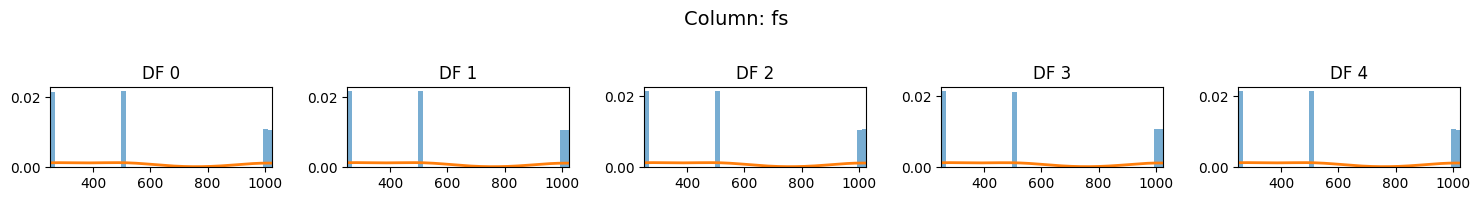

stat,df_0,df_1,df_2,df_3,df_4
str,f64,f64,f64,f64,f64
"""count""",196.0,196.0,195.0,195.0,195.0
"""min""",250.0,250.0,250.0,250.0,250.0
"""mean""",590.020408,586.193878,590.517949,593.082051,590.482051
"""median""",506.0,500.0,500.0,512.0,512.0
"""max""",1025.0,1025.0,1025.0,1025.0,1025.0
…,…,…,…,…,…
"""p90""",1025.0,1025.0,1025.0,1025.0,1025.0
"""p95""",1025.0,1025.0,1025.0,1025.0,1025.0
"""p97.5""",1025.0,1025.0,1025.0,1025.0,1025.0


In [9]:
REPEATS = 1
NUM_FOLDS = 5
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
splitter = sklearn.model_selection.RepeatedStratifiedKFold(n_splits=NUM_FOLDS, n_repeats = REPEATS, random_state=RANDOM_STATE)

cv_ret = {
    'splitter': splitter.__class__.__name__,
    'num_folds': NUM_FOLDS,
    'random_state': RANDOM_STATE,
    'folds': []
}

fold_val_dfs = []
for i, (train_indices, val_indices) in enumerate(splitter.split(df, df['fs'])):
    train_indices = train_indices.tolist()
    val_indices = val_indices.tolist()
    print(f"Fold {i}: train={len(train_indices)} val={len(val_indices)}")
    train_df = df[train_indices]
    val_df = df[val_indices]
    fold_val_dfs.append(val_df)
    train_image_ids = train_df['id'].to_list()
    val_image_ids = val_df['id'].to_list()
    cv_ret['folds'].append({
        'train_indices': train_indices,
        'val_indices': val_indices,
        'train_ids': train_image_ids,
        'val_ids': val_image_ids
    })


plot_histograms_and_stats(
    fold_val_dfs,
    COL_NAMES,
    bins=50,
    figsize_per_ax=(3, 2),
)

assert len(cv_ret['folds']) == NUM_FOLDS * REPEATS

SAVE_PATH = f'/home/dangnh36/datasets/ecg/processed/cv/v1/skf_{REPEATS}x{NUM_FOLDS}_rd{RANDOM_STATE}.json'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok = True)
with open(SAVE_PATH, 'w') as f:
    json.dump(cv_ret, f)